# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

In [1]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
#Paso1. Instalacion de dependencias
pip install pandas requests lxml


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Importar librerias para el paso 3
import pandas as pd
from io import StringIO

In [10]:
#Paso 2. Descargar HTML
url = "https://www.scrapethissite.com/pages/forms/"
response = requests.get(url)
html= response.text

print("Código de respuesta:", response.status_code)
print("Contenido HTML:", html_content)


Código de respuesta: 200
Contenido HTML: <!doctype html>
<html lang="en">
  <head>
    <meta charset="utf-8">
    <title>Hockey Teams: Forms, Searching and Pagination | Scrape This Site | A public sandbox for learning web scraping</title>
    <link rel="icon" type="image/png" href="/static/images/scraper-icon.png" />

    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <meta name="description" content="Browse through a database of NHL team stats since 1990. Practice building a scraper that handles common website interface components.">

    <link href="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.5/css/bootstrap.min.css" rel="stylesheet" integrity="sha256-MfvZlkHCEqatNoGiOXveE8FIwMzZg4W85qfrfIFBfYc= sha512-dTfge/zgoMYpP7QbHy4gWMEGsbsdZeCXz7irItjcC3sPUFtf0kuFbDz/ixG7ArTxmDjLXDmezHubeNikyKGVyQ==" crossorigin="anonymous">
    <link href='https://fonts.googleapis.com/css?family=Lato:400,700' rel='stylesheet' type='text/css'>
    <link rel="stylesheet" type="text

In [12]:
#Paso 3. Scraping de datos con BeautifulSoup
soup = BeautifulSoup(html_content, 'lxml')

tables = pd.read_html(StringIO(html))
df= tables[0]


In [13]:
#Paso 4. Procesa el DataFrame: limpiar las filas para obtener los valores que necesitemos
df = df.dropna(how="all")  # Eliminar filas completamente vacías
print (list(df.columns))
print(df.head())

['Team Name', 'Year', 'Wins', 'Losses', 'OT Losses', 'Win %', 'Goals For (GF)', 'Goals Against (GA)', '+ / -']
            Team Name  Year  Wins  Losses  OT Losses  Win %  Goals For (GF)  \
0       Boston Bruins  1990    44      24        NaN  0.550             299   
1      Buffalo Sabres  1990    31      30        NaN  0.388             292   
2      Calgary Flames  1990    46      26        NaN  0.575             344   
3  Chicago Blackhawks  1990    49      23        NaN  0.613             284   
4   Detroit Red Wings  1990    34      38        NaN  0.425             273   

   Goals Against (GA)  + / -  
0                 264     35  
1                 278     14  
2                 263     81  
3                 211     73  
4                 298    -25  


In [14]:
print(df.columns.tolist()) #Quiero saber el nombre exacto de las columnas para el paso 5.

['Team Name', 'Year', 'Wins', 'Losses', 'OT Losses', 'Win %', 'Goals For (GF)', 'Goals Against (GA)', '+ / -']


In [21]:
#Paso 5. Almacena los datos en SQlite
# 1. Crear conexión (como el archivo es nuevo: lo llamo 'hockey.db')",
conexion = sqlite3.connect('hockey.db')

#2, Crear un cursor para ejecutar consultas SQL",
cursor = conexion.cursor()

#3. Crear una tabla (si no existe) para almacenar los datos",
cursor.execute('''
    CREATE TABLE IF NOT EXISTS equipos (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        team_name TEXT,
        year INTEGER,
        wins INTEGER,
        losses INTEGER,
        ot_losses TEXT,
        win_pct TEXT,
        goals_for INTEGER,
        goals_against INTEGER,
        diff INTEGER
    )
''')
#Insertar los datos del DataFrame en la tabla de la base de datos
for _, fila in df.iterrows():
    cursor.execute('''
        INSERT INTO equipos (team_name, year, wins, losses, ot_losses, win_pct, goals_for, goals_against, diff)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    ''', (
        fila['Team Name'],
        fila['Year'],
        fila['Wins'],
        fila['Losses'],
        fila['OT Losses'],
        fila['Win %'],
        fila['Goals For (GF)'],
        fila['Goals Against (GA)'],
        fila['+ / -']
    ))

#Guardar los cambios y cerrar la conexión
conexion.commit()
print("Base de datos creada con éxito.")


Base de datos creada con éxito.


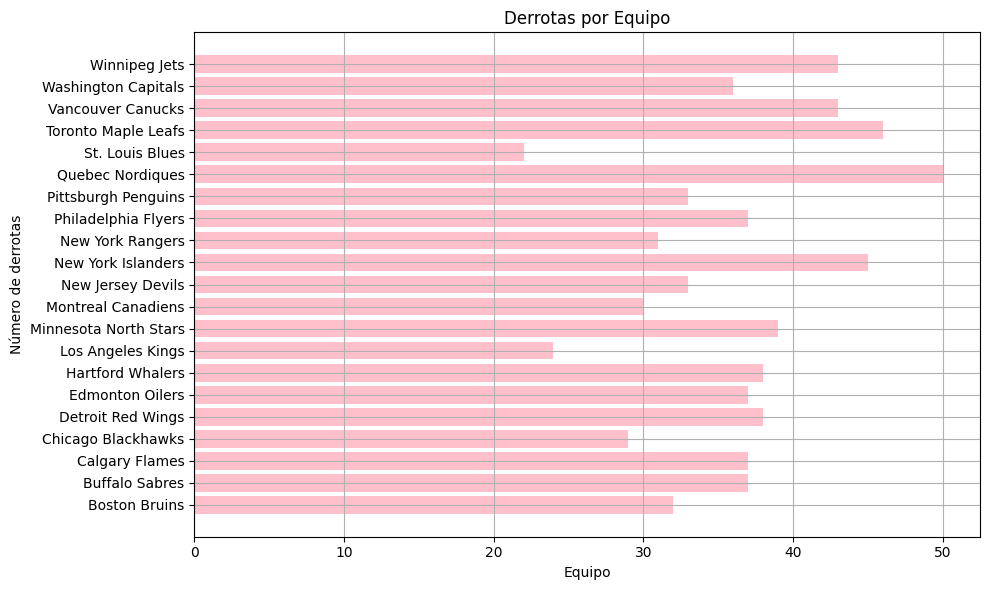

In [26]:
#Paso 6. Visualización de datos 
#Gráfico 1. Representar los datos de derrotas por equipo con un gráfico de barras

plt.figure (figsize=(10, 6))
plt.barh(df['Team Name'], df['Losses'], color='pink')

plt.title ('Derrotas por Equipo')
plt.xlabel ('Equipo')
plt.ylabel ('Número de derrotas')
plt.grid ()


plt.tight_layout()
plt.show()

En esta gráfica podemos ver de forma clara cuál ha sido el equipo que más derrotas ha acumulado, en este caso Quebec Nordiques, y el que menos el St. Louis Blues. Dado que son muchos equipos, he decidido hacer un gráfico de barras horizontal para que sean más legibles las variables

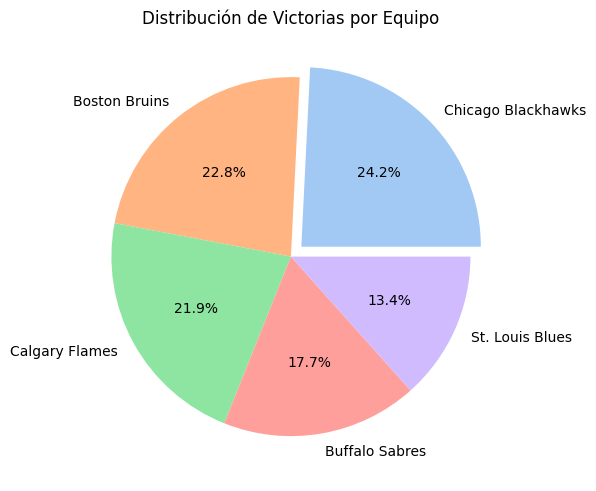

In [24]:
#Gráfico 2. Representar la distribución de victorias por equipo con un gráfico de pastel

explode = [0.08, 0, 0, 0, 0] #separa “Snacks"
top5 = df.groupby('Team Name')['Wins'].sum().sort_values(ascending=False).head(5) #Seleccionar los 5 equipos con más victorias
plt.figure(figsize=(6,6))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%', explode=explode, colors= sns.color_palette('pastel'))
plt.title ('Distribución de Victorias por Equipo')
plt.tight_layout()
plt.show()

En este gráfico hemos distribuido al top5 de ganadores por equipo, para mostrar la proporción de victorias que tiene cada uno en comparación con los demás. El equipo "Chicago Blchawks" se ha separado un poco del resto para destacarlo en el gráfico, dado que es el de mayor porcentaje.

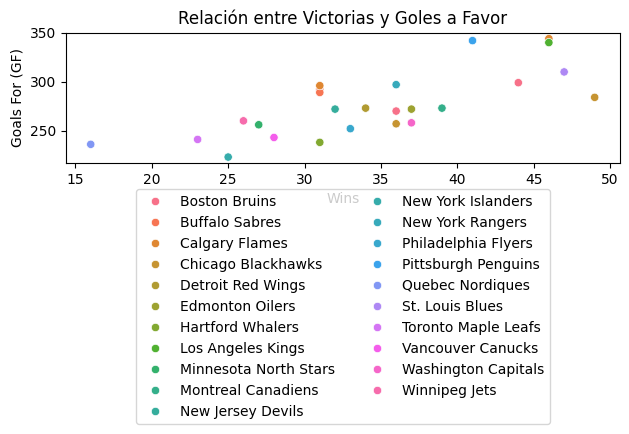

In [25]:
#Gráfico 3. 
sns.scatterplot(data=df, x='Wins', y='Goals For (GF)', hue='Team Name')
plt.title ('Relación entre Victorias y Goles a Favor')

#Posicionar la leyenda abajo, ncol=2 para que se muestre en 2 columnas
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

Y finalmente, con este gráfico de dispersion podemos valorar si existe una relación entre el número de victorias y los goles a favor. En general, podríamos esperar que los equipos con más victorias también tengan más goles a favor, lo que se reflejaría en una tendencia ascendente en el gráfico. Sin embargo, es importante analizar los datos para confirmar esta relación y considerar otros factores que podrían influir en el rendimiento del equipo.